# SFT 첫 파인튜닝 실습

> Phase 3에서 준비한 데이터와 01에서 배운 LoRA를 결합하여 **실제로 모델을 학습**시킨다

이 노트북에서 처음으로 모델이 '학습'한다.  
Qwen 2.5 1.5B를 사용하여 GPU가 제한적인 환경에서도 실행 가능하도록 구성했다.

In [1]:
# === 환경 설치 ===
!pip install datasets transformers peft accelerate trl bitsandbytes matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    BitsAndBytesConfig,
)
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# GPU 확인
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("GPU 없음 - CPU 모드 (매우 느림, 학습 스텝 수를 줄여서 실행)")

c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 4070 Ti (12.0 GB)


---
## 1. 데이터 준비

Phase 3 파이프라인의 출력을 재현한다.  
Alpaca 데이터를 로드하고, Chat Template으로 변환한다.

In [3]:
# === 데이터 로드 및 Phase 3 스타일 정제 ===

dataset = load_dataset("tatsu-lab/alpaca")
train_full = dataset['train']

# 실습용 소규모 데이터 (GPU 메모리 절약)
data = train_full.shuffle(seed=42).select(range(500))

# 기초 필터링
data = data.filter(lambda x: len(x['output'].strip()) >= 30)
data = data.filter(lambda x: len(x['output']) <= 3000)
data = data.filter(lambda x: len(x['instruction'].strip()) > 0)

print(f"정제 후 데이터: {len(data)}개")
print(f"샘플: {data[0]['instruction'][:60]}...")

정제 후 데이터: 441개
샘플: What would be the best type of exercise for a person who has...


In [4]:
# === Chat Template 변환 ===
# Qwen 2.5의 ChatML 형식에 맞게 변환

def format_to_chatml(sample):
    """Alpaca 형식 -> ChatML 형식"""
    if sample.get('input') and sample['input'].strip():
        user_msg = f"{sample['instruction']}\n\nInput: {sample['input']}"
    else:
        user_msg = sample['instruction']
    
    text = (
        f"<|im_start|>user\n{user_msg}<|im_end|>\n"
        f"<|im_start|>assistant\n{sample['output']}<|im_end|>"
    )
    return {"text": text}

data_formatted = data.map(format_to_chatml)

# Train / Validation 분할
split = data_formatted.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
val_data = split['test']

print(f"Train: {len(train_data)}개")
print(f"Val:   {len(val_data)}개")
print(f"\n샘플 (ChatML):")
print(train_data[0]['text'][:300])
print("...")

Train: 396개
Val:   45개

샘플 (ChatML):
<|im_start|>user
Design a program that calculates the average of five numbers<|im_end|>
<|im_start|>assistant
"""
Calculate the average of five numbers
"""

def calculate_average(numbers):
    average = sum(numbers) / len(numbers)
    return average

if __name__ == '__main__':
    numbers = [3, 6, 9
...


---
## 2. 모델 로드

Qwen 2.5 1.5B Instruct를 사용한다.  
- GPU 있으면: QLoRA (4-bit)
- GPU 없으면: GPT-2 (124M) + LoRA로 대체

In [5]:
# === 모델 로드 ===

if torch.cuda.is_available():
    # GPU 환경: Qwen 2.5 1.5B + QLoRA
    model_name = "Qwen/Qwen2.5-1.5B-Instruct"
    
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    model = prepare_model_for_kbit_training(model)
    
    print(f"모델: {model_name} (QLoRA 4-bit)")
    
else:
    # CPU 환경: GPT-2로 대체 (원리 학습용)
    model_name = "gpt2"
    model = AutoModelForCausalLM.from_pretrained(model_name)
    print(f"모델: {model_name} (CPU 모드 - 원리 학습용)")
    print("  주의: GPU 없이는 학습이 매우 느립니다")

tokenizer = AutoTokenizer.from_pretrained(model_name)

# 패딩 토큰 설정 (없는 모델이 많음)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

# 모델 메모리 사용량
param_bytes = sum(p.nelement() * p.element_size() for p in model.parameters())
print(f"모델 메모리: {param_bytes / (1024**3):.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!
Exception in thread Thread-7 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\jskim\anaconda3\envs\distillation\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte
Loading weights: 100%|██████████| 338/338 [00:01<00:00, 204.10it/s, Materializing param=model.norm.weight]                              


모델: Qwen/Qwen2.5-1.5B-Instruct (QLoRA 4-bit)
모델 메모리: 1.48 GB


---
## 3. LoRA 적용

In [6]:
# === LoRA 설정 및 적용 ===

if "qwen" in model_name.lower():
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"]
elif "gpt2" in model_name.lower():
    target_modules = ["c_attn", "c_proj"]
else:
    target_modules = ["q_proj", "v_proj"]

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=target_modules,
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

print(f"\nLoRA 설정:")
print(f"  r={lora_config.r}, alpha={lora_config.lora_alpha}, alpha/r={lora_config.lora_alpha/lora_config.r}")
print(f"  target: {target_modules}")

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820

LoRA 설정:
  r=16, alpha=32, alpha/r=2.0
  target: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


---
## 4. 학습 전 추론 (Before)

학습 전 모델의 응답을 기록해둔다. 학습 후와 비교하기 위해.

In [7]:
# === 학습 전 추론 ===

test_prompts = [
    "Explain the difference between a list and a tuple in Python.",
    "Write a SQL query to find the top 5 customers by total order amount.",
    "What is the capital of South Korea?",
]

def generate_response(model, tokenizer, prompt, max_new_tokens=100):
    """모델로 텍스트 생성"""
    # ChatML 형식으로 래핑
    formatted = f"<|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n"
    
    inputs = tokenizer(formatted, return_tensors="pt")
    if torch.cuda.is_available():
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    # 입력 부분 제거하고 생성된 부분만 반환
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated.strip()

print("학습 전 응답:")
print("=" * 60)
before_responses = []
for prompt in test_prompts:
    response = generate_response(peft_model, tokenizer, prompt)
    before_responses.append(response)
    print(f"\nQ: {prompt}")
    print(f"A: {response[:200]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


학습 전 응답:

Q: Explain the difference between a list and a tuple in Python.
A: In Python, both lists and tuples are used to store collections of items. However, there is a key difference between them:

1. Mutability:
   - Lists: Lists are mutable, meaning that you can change the

Q: Write a SQL query to find the top 5 customers by total order amount.
A: To find the top 5 customers by their total order amounts, you can use the following SQL query:

```sql
SELECT customer_id, SUM(order_amount) as total_order_amount
FROM orders
GROUP BY customer_id
ORDE

Q: What is the capital of South Korea?
A: The capital of South Korea is Seoul.


---
## 5. SFTTrainer로 학습 실행

TRL의 SFTTrainer가 데이터 토큰화, 패딩, 학습 루프를 모두 처리한다.

In [12]:
# === Training Arguments ===
# 각 인자의 의미를 정확히 이해하고 설정

from trl import SFTConfig

output_dir = "./output/sft_first_run"

training_args = SFTConfig(
    output_dir=output_dir,
    
    # === 배치 사이즈 ===
    per_device_train_batch_size=2,     # GPU당 배치 크기
    gradient_accumulation_steps=8,     # 그래디언트 누적 (실효 배치=2×8=16)
    # -> 실효 배치가 클수록 학습 안정적, 메모리는 per_device만 영향
    
    # === 학습 스케줄 ===
    num_train_epochs=3,               # 전체 데이터 3회 반복
    learning_rate=2e-4,               # LoRA 표준 학습률
    warmup_ratio=0.03,                # 처음 3% 동안 학습률 점진적 증가
    lr_scheduler_type="cosine",       # 코사인 감쇠 (자연스러운 수렴)
    
    # === 정밀도 ===
    fp16=False,   # GPU 있으면 fp16 학습
    bf16=torch.cuda.is_available(),
    
    # === 로깅 ===
    logging_steps=5,                  # 5 스텝마다 loss 기록
    logging_first_step=True,
    
    # === 체크포인트 ===
    save_strategy="epoch",            # 에폭마다 저장
    eval_strategy="epoch",            # 에폭마다 평가
    save_total_limit=2,               # 최근 2개만 유지
    load_best_model_at_end=True,      # 최고 성능 모델 자동 로드
    
    # === SFT 전용 ===
    max_length=512,                   # Phase 3 데이터 카드: 평균 110, 최대 272 토큰
    dataset_text_field="text",        # 학습에 사용할 텍스트 필드명
    
    # === 기타 ===
    gradient_checkpointing=True,       # 메모리 절약 (속도 약간 감소)
    max_grad_norm=1.0,                # 그래디언트 클리핑
    report_to="none",                 # W&B 등 외부 로깅 비활성화
    seed=42,
)

print("Training Arguments 요약:")
print("=" * 50)
print(f"  실효 배치 크기: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  에폭:          {training_args.num_train_epochs}")
print(f"  학습률:        {training_args.learning_rate}")
print(f"  스케줄러:      {training_args.lr_scheduler_type}")
print(f"  Warmup:        {training_args.warmup_ratio*100:.0f}%")
print(f"  정밀도:        {'fp16' if training_args.fp16 else 'fp32'}")
print(f"  max_length:    {training_args.max_length}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Arguments 요약:
  실효 배치 크기: 16
  에폭:          3
  학습률:        0.0002
  스케줄러:      cosine
  Warmup:        3%
  정밀도:        fp32
  max_length:    512


In [13]:
# === SFTTrainer 생성 및 학습 ===

trainer = SFTTrainer(
    model=peft_model,
    processing_class=tokenizer,
    train_dataset=train_data,
    eval_dataset=val_data,
    args=training_args,
)

print(f"학습 시작:")
print(f"  Train 샘플: {len(train_data)}")
print(f"  Val 샘플:   {len(val_data)}")
print(f"  Max length:  {training_args.max_length}")
print(f"  예상 스텝:   {len(train_data) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps) * int(training_args.num_train_epochs)}")
print("\n학습 중...")

result = trainer.train()

print(f"\n학습 완료!")
print(f"  총 스텝: {result.global_step}")
print(f"  최종 loss: {result.training_loss:.4f}")

학습 시작:
  Train 샘플: 396
  Val 샘플:   45
  Max length:  512
  예상 스텝:   72

학습 중...


Epoch,Training Loss,Validation Loss
1,1.435100,1.488963
2,1.265491,1.482229
3,1.130902,1.486071



학습 완료!
  총 스텝: 75
  최종 loss: 1.3375


---
## 6. Loss 그래프 분석

학습이 정상적으로 진행되었는지 Loss 그래프로 판단한다.  
Phase 5 트러블슈팅의 기초가 되는 필수 스킬이다.

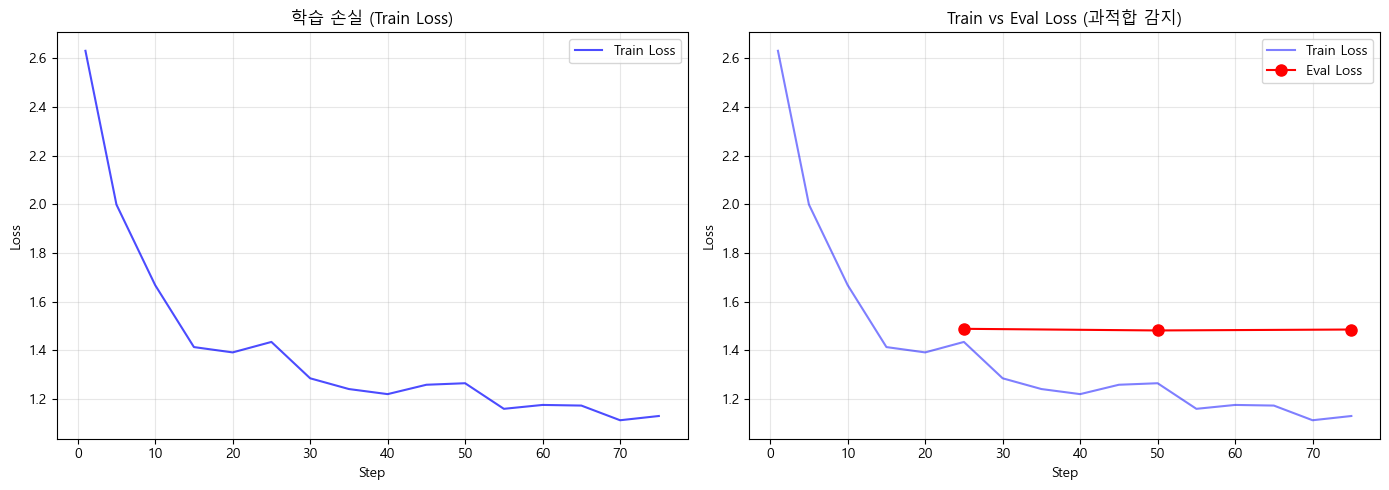


Loss 분석:
  시작: 2.6306
  종료: 1.1309
  감소: 57.0%

Loss 해석 가이드:
  - 꾸준히 감소 -> 정상 학습
  - 초반 급감 후 정체 -> 수렴 (정상)
  - 감소하다 다시 상승 -> 과적합 의심
  - 전혀 안 떨어짐 -> 학습률 문제
  - NaN 발생 -> 학습률 너무 높거나 데이터 문제

  Train-Eval Gap: 0.3552
  -> 양호: 과적합 없음


In [14]:
# === Loss 그래프 시각화 ===

# 학습 로그에서 loss 추출
log_history = trainer.state.log_history

train_losses = [(log['step'], log['loss']) 
                for log in log_history if 'loss' in log]
eval_losses = [(log['step'], log['eval_loss']) 
               for log in log_history if 'eval_loss' in log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Train Loss
if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, 'b-', alpha=0.7, label='Train Loss')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('학습 손실 (Train Loss)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# 2) Train vs Eval Loss
if eval_losses:
    eval_steps, eval_loss_vals = zip(*eval_losses)
    axes[1].plot(steps, losses, 'b-', alpha=0.5, label='Train Loss')
    axes[1].plot(eval_steps, eval_loss_vals, 'ro-', label='Eval Loss', markersize=8)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Train vs Eval Loss (과적합 감지)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Loss 해석 가이드
if train_losses:
    first_loss = train_losses[0][1]
    last_loss = train_losses[-1][1]
    print(f"\nLoss 분석:")
    print(f"  시작: {first_loss:.4f}")
    print(f"  종료: {last_loss:.4f}")
    print(f"  감소: {(1 - last_loss/first_loss) * 100:.1f}%")
    
    print(f"\nLoss 해석 가이드:")
    print(f"  - 꾸준히 감소 -> 정상 학습")
    print(f"  - 초반 급감 후 정체 -> 수렴 (정상)")
    print(f"  - 감소하다 다시 상승 -> 과적합 의심")
    print(f"  - 전혀 안 떨어짐 -> 학습률 문제")
    print(f"  - NaN 발생 -> 학습률 너무 높거나 데이터 문제")
    
    if eval_losses:
        last_eval = eval_losses[-1][1]
        gap = last_eval - last_loss
        print(f"\n  Train-Eval Gap: {gap:.4f}")
        if gap > 0.5:
            print(f"  -> 과적합 위험: 데이터 증강 또는 epoch 줄이기 고려")
        else:
            print(f"  -> 양호: 과적합 없음")

---
## 7. 학습 후 추론 (After) 및 비교

In [15]:
# === 학습 후 추론 및 Before/After 비교 ===

peft_model.eval()

print("Before vs After 비교:")
print("=" * 60)

for i, prompt in enumerate(test_prompts):
    after_response = generate_response(peft_model, tokenizer, prompt)
    
    print(f"\n{'─' * 60}")
    print(f"Q: {prompt}")
    print(f"\n[Before] {before_responses[i][:200]}")
    print(f"\n[After]  {after_response[:200]}")

Before vs After 비교:

────────────────────────────────────────────────────────────
Q: Explain the difference between a list and a tuple in Python.

[Before] In Python, both lists and tuples are used to store collections of items. However, there is a key difference between them:

1. Mutability:
   - Lists: Lists are mutable, meaning that you can change the

[After]  A list is an ordered collection of items, while a tuple is an immutable (read-only) ordered collection of items. Lists are mutable, meaning that their elements can be changed after they have been crea

────────────────────────────────────────────────────────────
Q: Write a SQL query to find the top 5 customers by total order amount.

[Before] To find the top 5 customers by their total order amounts, you can use the following SQL query:

```sql
SELECT customer_id, SUM(order_amount) as total_order_amount
FROM orders
GROUP BY customer_id
ORDE

[After]  SELECT customer_id, SUM(order_amount) as total_order_amount 
FROM orders 
GRO

---
## 8. 모델 저장과 로드

LoRA 어댑터만 저장한다 (수 MB). 원본 모델은 HuggingFace에서 다시 받으면 된다.

In [16]:
# === LoRA 어댑터 저장 ===

adapter_path = "./output/sft_first_run/final_adapter"
peft_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

import os

# 저장된 파일 확인
print("저장된 파일:")
total_size = 0
for f in os.listdir(adapter_path):
    fpath = os.path.join(adapter_path, f)
    size = os.path.getsize(fpath)
    total_size += size
    print(f"  {f}: {size / 1024:.1f} KB")

print(f"\n총 크기: {total_size / (1024**2):.1f} MB")
print(f"\n-> 원본 모델: 수 GB / LoRA 어댑터: 수 MB")
print(f"   100개의 다른 태스크에 각각 파인튜닝해도 어댑터만 바꿔 끼우면 됨")

저장된 파일:
  adapter_config.json: 1.1 KB
  adapter_model.safetensors: 72178.8 KB
  chat_template.jinja: 2.5 KB
  README.md: 5.1 KB
  tokenizer.json: 11154.2 KB
  tokenizer_config.json: 0.7 KB

총 크기: 81.4 MB

-> 원본 모델: 수 GB / LoRA 어댑터: 수 MB
   100개의 다른 태스크에 각각 파인튜닝해도 어댑터만 바꿔 끼우면 됨


In [17]:
# === 저장된 어댑터 다시 로드 ===
from peft import PeftModel

print("어댑터 로드 방법:")
print("=" * 50)
print(f"""
# 1) 원본 모델 로드
base_model = AutoModelForCausalLM.from_pretrained("{model_name}")

# 2) LoRA 어댑터 붙이기
model = PeftModel.from_pretrained(base_model, "{adapter_path}")

# 3) 추론 최적화: LoRA를 원본에 병합 (선택)
model = model.merge_and_unload()
# -> 병합 후에는 순수 Transformer 모델 (추론 속도 동일)
""")

print("merge_and_unload()의 의미:")
print("  학습: W' = W + (alpha/r) × B·A  (W와 BA가 분리)")
print("  병합: W_merged = W + (alpha/r) × B·A  (하나로 합침)")
print("  -> 추론 시 추가 연산 없음, 원본 모델과 동일한 속도")

어댑터 로드 방법:

# 1) 원본 모델 로드
base_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")

# 2) LoRA 어댑터 붙이기
model = PeftModel.from_pretrained(base_model, "./output/sft_first_run/final_adapter")

# 3) 추론 최적화: LoRA를 원본에 병합 (선택)
model = model.merge_and_unload()
# -> 병합 후에는 순수 Transformer 모델 (추론 속도 동일)

merge_and_unload()의 의미:
  학습: W' = W + (alpha/r) × B·A  (W와 BA가 분리)
  병합: W_merged = W + (alpha/r) × B·A  (하나로 합침)
  -> 추론 시 추가 연산 없음, 원본 모델과 동일한 속도


---
## 9. 학습 결과 요약 시각화

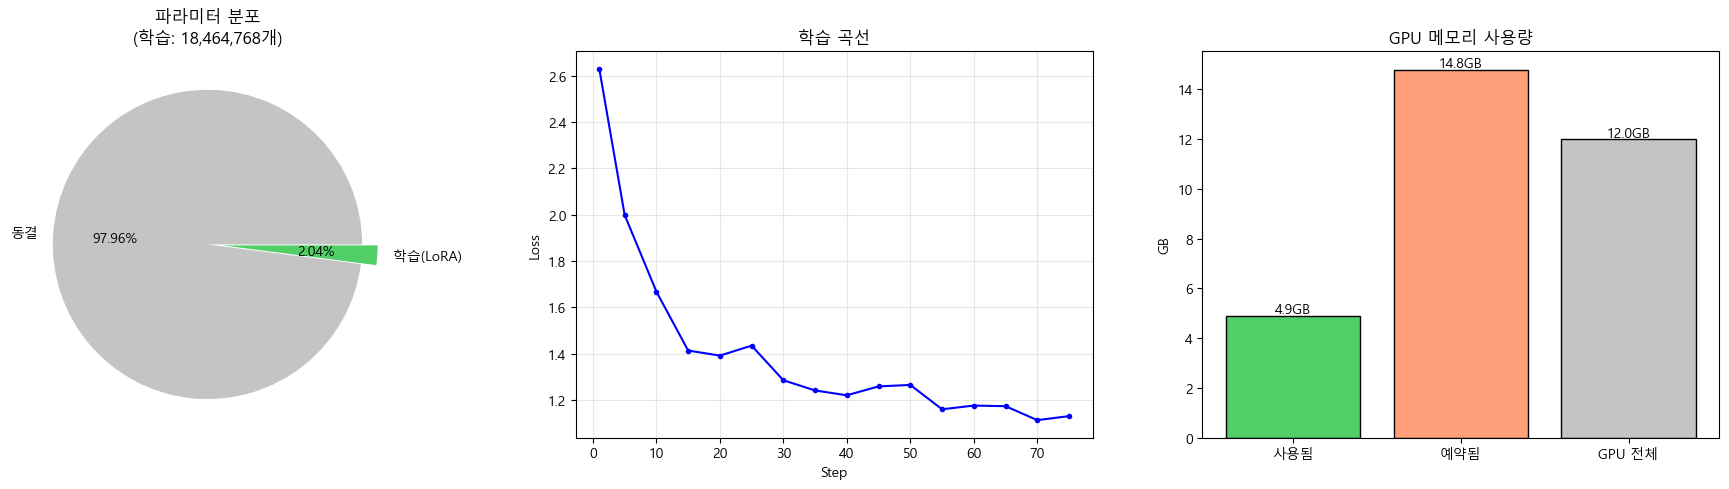


학습 요약:
  모델: Qwen/Qwen2.5-1.5B-Instruct
  LoRA r=16, alpha=32
  데이터: 396 train / 45 val
  에폭: 3
  Loss: 2.6306 -> 1.1309
  어댑터 크기: 81.4 MB


In [18]:
# === 학습 결과 종합 시각화 ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 파라미터 비교
total = sum(p.numel() for p in peft_model.parameters())
trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
frozen = total - trainable

axes[0].pie([frozen, trainable], 
           labels=['동결', '학습(LoRA)'],
           autopct='%1.2f%%',
           colors=['#c4c4c4', '#51cf66'],
           explode=[0, 0.1])
axes[0].set_title(f'파라미터 분포\n(학습: {trainable:,}개)')

# 2) Loss 추이
if train_losses:
    steps, losses = zip(*train_losses)
    axes[1].plot(steps, losses, 'b-o', markersize=3)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('학습 곡선')
    axes[1].grid(True, alpha=0.3)

# 3) 메모리 사용량
if torch.cuda.is_available():
    allocated = torch.cuda.max_memory_allocated() / (1024**3)
    reserved = torch.cuda.max_memory_reserved() / (1024**3)
    gpu_total = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    
    bars = axes[2].bar(['사용됨', '예약됨', 'GPU 전체'], 
                       [allocated, reserved, gpu_total],
                       color=['#51cf66', '#ffa07a', '#c4c4c4'],
                       edgecolor='black')
    axes[2].set_ylabel('GB')
    axes[2].set_title('GPU 메모리 사용량')
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:.1f}GB', ha='center')
else:
    axes[2].text(0.5, 0.5, 'GPU 없음', ha='center', va='center', fontsize=14)
    axes[2].set_title('GPU 메모리 (N/A)')

plt.tight_layout()
plt.show()

print("\n학습 요약:")
print(f"  모델: {model_name}")
print(f"  LoRA r={lora_config.r}, alpha={lora_config.lora_alpha}")
print(f"  데이터: {len(train_data)} train / {len(val_data)} val")
print(f"  에폭: {training_args.num_train_epochs}")
if train_losses:
    print(f"  Loss: {train_losses[0][1]:.4f} -> {train_losses[-1][1]:.4f}")
print(f"  어댑터 크기: {total_size / (1024**2):.1f} MB")

---
## 정리

| 단계 | 내용 | 핵심 |
|------|------|------|
| **데이터** | Phase 3 출력 → ChatML 변환 | SFTTrainer에 text 필드로 전달 |
| **모델** | Qwen 2.5 1.5B + QLoRA | 4-bit 로드로 메모리 절약 |
| **LoRA** | r=16, alpha=32 | 전체의 ~1%만 학습 |
| **학습** | SFTTrainer, 3 epoch | gradient accumulation으로 실효 배치 확보 |
| **분석** | Loss 그래프 해석 | 과적합/발산 여부 판단 |
| **저장** | 어댑터만 저장 (수 MB) | merge_and_unload()로 병합 가능 |

### 다음: 03_Text_to_SQL_프로젝트.ipynb

실전 프로젝트로 확장:
- Text-to-SQL 전용 데이터셋 사용
- 도메인 특화 파인튜닝
- SQL 정확도로 실제 성능 평가